# Tester Mistral Small 4 avec Transformers

Ce notebook suit l'exemple de la [documentation Transformers](https://huggingface.co/docs/transformers/model_doc/mistral4) pour `mistralai/Mistral-Small-4-119B-2603`. Le modèle totalise 119 milliards de paramètres : même si seulement une partie des experts est activée par token, tous les poids doivent être chargés. Le chargement BF16 est donc une opération lourde.

Le contrôle GPU effectué avant la création a trouvé quatre H100 NVL : les GPU physiques 0, 2 et 3 étaient libres (environ 94 Gio chacun), tandis que le GPU 1 était déjà utilisé par un serveur vLLM. Le notebook masque le GPU 1 et réserve une marge mémoire sur les trois autres. N'exécutez pas la cellule de chargement si une autre tâche a depuis pris ces GPU.

In [21]:
from pathlib import Path
import sys

if Path(sys.prefix).name != ".venv-mistral4":
    raise RuntimeError(
        "Sélectionnez le kernel « Python (Mistral4) » dans VS Code. "
        f"Kernel actif : {sys.executable}"
    )

print(f"Kernel dédié actif : {sys.executable}")

Kernel dédié actif : /home/cbenavent/test/Mistral4/.venv-mistral4/bin/python


Dans le sélecteur de kernel en haut du notebook, choisissez **Python (Mistral4)**. Exécutez cette cellule de configuration avant toute cellule qui initialise CUDA pour masquer le GPU physique 1. Si elle indique que CUDA est déjà initialisé avec le masque `0,2,3`, vous pouvez continuer ; avec un autre masque, redémarrez le kernel puis reprenez dans l’ordre.

In [22]:
import os
import torch

GPU_MASK = "0,2,3"
if torch.cuda.is_initialized():
    current_gpu_mask = os.environ.get("CUDA_VISIBLE_DEVICES")
    if current_gpu_mask != GPU_MASK or torch.cuda.device_count() != 3:
        raise RuntimeError(
            "CUDA est déjà initialisé sans le masque GPU attendu. "
            "Redémarrez le kernel et exécutez cette cellule avant toute cellule qui utilise CUDA."
        )
    print(f"CUDA déjà initialisé avec le masque attendu : {current_gpu_mask}")
else:
    os.environ["CUDA_VISIBLE_DEVICES"] = GPU_MASK
    print(f"GPU physiques exposés au kernel : {GPU_MASK}")

CUDA déjà initialisé avec le masque attendu : 0,2,3


In [23]:
import torch
import transformers

print(f"PyTorch : {torch.__version__}")
print(f"Transformers : {transformers.__version__}")
assert torch.cuda.is_available(), "Aucun GPU CUDA visible dans ce kernel."
assert torch.cuda.device_count() == 3, (
    f"3 GPU étaient attendus, {torch.cuda.device_count()} sont visibles. "
    "Vérifiez CUDA_VISIBLE_DEVICES et la disponibilité des GPU."
)

for device_index in range(torch.cuda.device_count()):
    free_bytes, total_bytes = torch.cuda.mem_get_info(device_index)
    print(
        f"cuda:{device_index} ({torch.cuda.get_device_name(device_index)}): "
        f"{free_bytes / 1024**3:.1f} Gio libres / {total_bytes / 1024**3:.1f} Gio"
    )

PyTorch : 2.9.1+cu128
Transformers : 5.18.0
cuda:0 (NVIDIA H100 NVL): 51.1 Gio libres / 93.1 Gio
cuda:1 (NVIDIA H100 NVL): 52.2 Gio libres / 93.1 Gio
cuda:2 (NVIDIA H100 NVL): 54.2 Gio libres / 93.1 Gio


## Chargement du modèle

Cette cellule télécharge les poids du modèle et peut prendre du temps. La limite de 88 Gio par GPU garde une marge pour le contexte CUDA et la génération. Elle n'annule pas les autres tâches qui pourraient utiliser ces GPU.

In [24]:
from transformers import AutoProcessor, Mistral3ForConditionalGeneration
from transformers.integrations.hub_kernels import lazy_load_kernel

MODEL_ID = "mistralai/Mistral-Small-4-119B-2603"
MAX_MEMORY = {0: "88GiB", 1: "88GiB", 2: "88GiB"}

fp8_kernel = lazy_load_kernel("finegrained-fp8")
print("Kernel de calcul FP8 chargé.")

processor = AutoProcessor.from_pretrained(MODEL_ID)
model = Mistral3ForConditionalGeneration.from_pretrained(
    MODEL_ID,
    dtype=torch.bfloat16,
    device_map="auto",
    max_memory=MAX_MEMORY,
    low_cpu_mem_usage=True,
)

print("Répartition des poids :")
for module_name, device in model.hf_device_map.items():
    print(f"{module_name or '<modèle>'}: {device}")

offloaded = {device for device in model.hf_device_map.values() if str(device) in {"cpu", "disk"}}
if offloaded:
    print(f"Attention : des poids sont déportés vers {sorted(offloaded)} ; l'inférence peut être très lente.")

Kernel de calcul FP8 chargé.


Loading weights: 100%|██████████| 1485/1485 [00:23<00:00, 63.38it/s] 


Répartition des poids :
model.vision_tower: 0
model.multi_modal_projector: 0
model.language_model.embed_tokens: 0
model.language_model.layers.0: 0
model.language_model.layers.1: 0
model.language_model.layers.2: 0
model.language_model.layers.3: 0
model.language_model.layers.4: 0
model.language_model.layers.5: 0
model.language_model.layers.6: 0
model.language_model.layers.7: 0
model.language_model.layers.8: 0
model.language_model.layers.9: 0
model.language_model.layers.10: 0
model.language_model.layers.11: 1
model.language_model.layers.12: 1
model.language_model.layers.13: 1
model.language_model.layers.14: 1
model.language_model.layers.15: 1
model.language_model.layers.16: 1
model.language_model.layers.17: 1
model.language_model.layers.18: 1
model.language_model.layers.19: 1
model.language_model.layers.20: 1
model.language_model.layers.21: 1
model.language_model.layers.22: 1
model.language_model.layers.23: 1
model.language_model.layers.24: 2
model.language_model.layers.25: 2
model.langua

## Test de génération en français

Le test reste court pour limiter l'usage mémoire du cache de génération. Modifiez `REASONING_EFFORT` ou `MAX_NEW_TOKENS` pour explorer d'autres réglages.

In [25]:
import os
import sysconfig
import time
from pathlib import Path

python_include_dirs = [Path(sysconfig.get_path("include"))]
python_include_dirs.extend(Path.home().glob(".local/share/uv/python/cpython-3.11*/include/python3.11"))
python_include_dir = next(
    (directory for directory in python_include_dirs if (directory / "Python.h").is_file()),
    None,
)
if python_include_dir is None:
    raise RuntimeError(
        "Triton doit compiler un lanceur CUDA, mais Python.h est absent. "
        "Installez les en-têtes de développement Python 3.11."
    )

existing_cpath = os.environ.get("CPATH", "")
if str(python_include_dir) not in existing_cpath.split(os.pathsep):
    os.environ["CPATH"] = os.pathsep.join(filter(None, (str(python_include_dir), existing_cpath)))

REASONING_EFFORT = "none"
MAX_NEW_TOKENS = 128
messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "text",
                "text": "Explique en français, en deux phrases, pourquoi les feuilles changent de couleur en automne.",
            }
        ],
    }
]
inputs = processor.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=True,
    return_tensors="pt",
    return_dict=True,
    reasoning_effort=REASONING_EFFORT,
).to(model.device)
prompt_tokens = inputs["input_ids"].shape[-1]
model.set_experts_implementation("eager")
print("Dispatch des experts : eager")

for device_index in range(torch.cuda.device_count()):
    torch.cuda.reset_peak_memory_stats(device_index)
    torch.cuda.synchronize(device_index)

start_time = time.perf_counter()
with torch.inference_mode():
    output_ids = model.generate(
        **inputs,
        max_new_tokens=MAX_NEW_TOKENS,
        do_sample=False,
    )
for device_index in range(torch.cuda.device_count()):
    torch.cuda.synchronize(device_index)
elapsed_seconds = time.perf_counter() - start_time
generated_tokens = output_ids.shape[-1] - prompt_tokens
answer = processor.decode(output_ids[0, prompt_tokens:], skip_special_tokens=True)
print(f"Temps de génération : {elapsed_seconds:.2f} s")
print(f"Tokens générés : {generated_tokens}")
print(f"Débit : {generated_tokens / elapsed_seconds:.2f} tokens/s")
print(answer)
for device_index in range(torch.cuda.device_count()):
    peak_gib = torch.cuda.max_memory_allocated(device_index) / 1024**3
    print(f"Mémoire GPU max cuda:{device_index} : {peak_gib:.1f} Gio")

[transformers] Both `max_new_tokens` (=128) and `max_length`(=1048576) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Dispatch des experts : eager
Temps de génération : 16.35 s
Tokens générés : 75
Débit : 4.59 tokens/s
En automne, les feuilles changent de couleur car la diminution de la lumière et des températures fait baisser la production de chlorophylle, le pigment vert qui les nourrit pendant la saison de croissance. Sans ce pigment dominant, d'autres couleurs comme le jaune, l'orange ou le rouge, cachées par la chlorophylle, deviennent visibles.
Mémoire GPU max cuda:0 : 70.8 Gio
Mémoire GPU max cuda:1 : 79.4 Gio
Mémoire GPU max cuda:2 : 75.3 Gio


## Analyse des réponses : type de métier

Cette exécution analyse les transcripts combinés, affiche la progression et l’ETA, puis écrit les résultats dans `transcripts_job_types_full.csv`.

In [ ]:
import csv
import time
from pathlib import Path

from tqdm.auto import tqdm

response_candidates = [
    Path("transcripts_responses.csv"),
    Path("Mistral4/transcripts_responses.csv"),
]
response_path = next((path.resolve() for path in response_candidates if path.is_file()), None)
if response_path is None:
    raise FileNotFoundError(
        "Fichier transcripts_responses.csv introuvable. "
        "Exécutez d'abord le notebook de préparation des transcriptions."
    )

with response_path.open("r", encoding="utf-8", newline="") as source_file:
    reader = csv.DictReader(source_file)
    required_columns = {"transcript_id", "user_responses"}
    missing_columns = required_columns.difference(reader.fieldnames or [])
    if missing_columns:
        raise ValueError(f"Colonnes requises absentes : {sorted(missing_columns)}")
    response_rows = [
        {
            "transcript_id": row["transcript_id"],
            "user_responses": row["user_responses"],
        }
        for row in reader
        if row["user_responses"].strip()
    ]

SAMPLE_SIZE = None
BATCH_SIZE = 1
MAX_JOB_TYPE_TOKENS = 16
REASONING_EFFORT = "none"

analysis_rows = response_rows
if SAMPLE_SIZE is not None:
    analysis_rows = analysis_rows[:SAMPLE_SIZE]

model.set_experts_implementation("eager")
results = []
failures = 0
for device_index in range(torch.cuda.device_count()):
    torch.cuda.reset_peak_memory_stats(device_index)
    torch.cuda.synchronize(device_index)

start_time = time.perf_counter()
with tqdm(
    total=len(analysis_rows),
    desc="Analyse des métiers",
    unit="transcripts",
    dynamic_ncols=True,
) as progress:
    for batch_start in range(0, len(analysis_rows), BATCH_SIZE):
        batch = analysis_rows[batch_start : batch_start + BATCH_SIZE]
        for row in batch:
            try:
                messages = [
                    {
                        "role": "user",
                        "content": [
                            {
                                "type": "text",
                                "text": (
                                    "Pour le texte ci-dessous, indique en moins de 5 mots "
                                    "de quel type de métier il s'agit. Réponds uniquement "
                                    "par le type de métier.\n\n"
                                    f"Texte :\n{row['user_responses']}"
                                ),
                            }
                        ],
                    }
                ]
                inputs = processor.apply_chat_template(
                    messages,
                    tokenize=True,
                    add_generation_prompt=True,
                    return_tensors="pt",
                    return_dict=True,
                    reasoning_effort=REASONING_EFFORT,
                ).to(model.device)
                with torch.inference_mode():
                    output_ids = model.generate(
                        **inputs,
                        max_new_tokens=MAX_JOB_TYPE_TOKENS,
                        do_sample=False,
                    )
                raw_job_type = processor.decode(
                    output_ids[0, inputs["input_ids"].shape[-1] :],
                    skip_special_tokens=True,
                ).strip()
                job_type = " ".join(raw_job_type.split()[:4]).strip(" \t\n.,;:")
                results.append(
                    {
                        "transcript_id": row["transcript_id"],
                        "job_type": job_type,
                        "analysis_error": "",
                    }
                )
            except Exception as error:
                failures += 1
                results.append(
                    {
                        "transcript_id": row["transcript_id"],
                        "job_type": "",
                        "analysis_error": f"{type(error).__name__}: {error}",
                    }
                )
            progress.update(1)
            progress.set_postfix(traites=len(results), echecs=failures)

for device_index in range(torch.cuda.device_count()):
    torch.cuda.synchronize(device_index)
elapsed_seconds = time.perf_counter() - start_time
assert len(results) == len(analysis_rows), "Le nombre de résultats ne correspond pas à l'échantillon."

run_scope = "full" if SAMPLE_SIZE is None else f"sample{len(analysis_rows)}"
job_types_path = response_path.with_name(f"transcripts_job_types_{run_scope}.csv")
with job_types_path.open("w", encoding="utf-8", newline="") as output_file:
    writer = csv.DictWriter(
        output_file,
        fieldnames=["transcript_id", "job_type", "analysis_error"],
    )
    writer.writeheader()
    writer.writerows(results)

processed_per_second = len(results) / elapsed_seconds if elapsed_seconds else 0.0
print(f"Modèle : {MODEL_ID}")
print(f"Transcripts traités : {len(results)} / {len(analysis_rows)}")
print(f"Échecs : {failures}")
print(f"Temps total : {elapsed_seconds:.1f} s")
print(f"Débit : {processed_per_second:.3f} transcripts/s")
for device_index in range(torch.cuda.device_count()):
    peak_gib = torch.cuda.max_memory_allocated(device_index) / 1024**3
    print(f"Mémoire GPU max cuda:{device_index} : {peak_gib:.1f} Gio")
print(f"Résultats enregistrés : {job_types_path}")
print("Exemples :")
for result in results[:10]:
    print(result)

Analyse des métiers:   0%|          | 0/1250 [00:00<?, ?transcripts/s]

[transformers] Both `max_new_tokens` (=16) and `max_length`(=1048576) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Analyse des métiers:  91%|█████████ | 1140/1250 [55:04<05:34,  3.04s/transcripts, echecs=0, traites=1140][transformers] Both `max_new_tokens` (=16) and `max_length`(=1048576) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


## Analyse des aspects principaux de l’expérience vécue

Pour chaque transcript du corpus combiné, extraire jusqu’à sept aspects récurrents ou saillants de l’expérience professionnelle avec l’IA (usages, bénéfices, limites, préoccupations ou effets sur la pratique). Chaque aspect est formulé en quelques mots, sans interprétation qui ne soit pas étayée par les réponses. `ASPECT_SAMPLE_SIZE = None` lance l’analyse complète ; une valeur entière permet un essai déterministe sur les premières lignes.

In [ ]:
import csv
import re
import time
from pathlib import Path

from tqdm.auto import tqdm

aspect_response_candidates = [
    Path("transcripts_responses.csv"),
    Path("Mistral4/transcripts_responses.csv"),
]
aspect_response_path = next(
    (path.resolve() for path in aspect_response_candidates if path.is_file()),
    None,
)
if aspect_response_path is None:
    raise FileNotFoundError("Fichier transcripts_responses.csv introuvable.")

with aspect_response_path.open("r", encoding="utf-8", newline="") as source_file:
    aspect_reader = csv.DictReader(source_file)
    required_aspect_columns = {"transcript_id", "user_responses"}
    missing_aspect_columns = required_aspect_columns.difference(aspect_reader.fieldnames or [])
    if missing_aspect_columns:
        raise ValueError(f"Colonnes requises absentes : {sorted(missing_aspect_columns)}")
    aspect_rows = [
        {"transcript_id": row["transcript_id"], "user_responses": row["user_responses"]}
        for row in aspect_reader
        if row["user_responses"].strip()
    ]

ASPECT_SAMPLE_SIZE = None
ASPECT_BATCH_SIZE = 1
MAX_ASPECTS = 7
MAX_ASPECT_TOKENS = 96
ASPECT_REASONING_EFFORT = "none"
if ASPECT_SAMPLE_SIZE is not None:
    aspect_rows = aspect_rows[:ASPECT_SAMPLE_SIZE]

ASPECT_COLUMNS = [f"aspect_{index}" for index in range(1, MAX_ASPECTS + 1)]
model.set_experts_implementation("eager")
aspect_results = []
aspect_failures = 0
for device_index in range(torch.cuda.device_count()):
    torch.cuda.reset_peak_memory_stats(device_index)
    torch.cuda.synchronize(device_index)

aspect_start_time = time.perf_counter()
with tqdm(
    total=len(aspect_rows),
    desc="Analyse des aspects vécus",
    unit="transcripts",
    dynamic_ncols=True,
) as aspect_progress:
    for batch_start in range(0, len(aspect_rows), ASPECT_BATCH_SIZE):
        batch = aspect_rows[batch_start : batch_start + ASPECT_BATCH_SIZE]
        for row in batch:
            try:
                messages = [
                    {
                        "role": "user",
                        "content": [
                            {
                                "type": "text",
                                "text": (
                                    "Analyse les réponses de cette personne sur son expérience de l’IA dans son travail professionnel. "
                                    f"Identifie jusqu’à {MAX_ASPECTS} aspects principaux de l’expérience vécue, "
                                    "par exemple les usages, les bénéfices, les limites, les préoccupations ou les effets sur la pratique. "
                                    "Ne retiens que les aspects explicitement étayés par le texte. "
                                    "Réponds uniquement avec un aspect par ligne, en 2 à 5 mots par aspect, sans numérotation ni explication. "
                                    "S’il n’y a pas assez d’information, réponds : Information insuffisante.\n\n"
                                    f"Réponses :\n{row['user_responses']}"
                                ),
                            }
                        ],
                    }
                ]
                aspect_inputs = processor.apply_chat_template(
                    messages,
                    tokenize=True,
                    add_generation_prompt=True,
                    return_tensors="pt",
                    return_dict=True,
                    reasoning_effort=ASPECT_REASONING_EFFORT,
                ).to(model.device)
                with torch.inference_mode():
                    aspect_output_ids = model.generate(
                        **aspect_inputs,
                        max_new_tokens=MAX_ASPECT_TOKENS,
                        do_sample=False,
                    )
                raw_aspects = processor.decode(
                    aspect_output_ids[0, aspect_inputs["input_ids"].shape[-1] :],
                    skip_special_tokens=True,
                ).strip()
                aspect_lines = [
                    re.sub(r"^[-*•\d.)\s]+", "", line).strip(" \t.,;:")
                    for line in raw_aspects.splitlines()
                ]
                aspect_lines = [
                    " ".join(line.split()[:5])
                    for line in aspect_lines
                    if line and "information insuffisante" not in line.casefold()
                ][:MAX_ASPECTS]
                result_row = {"transcript_id": row["transcript_id"], "analysis_error": ""}
                result_row.update({
                    column: aspect_lines[index] if index < len(aspect_lines) else ""
                    for index, column in enumerate(ASPECT_COLUMNS)
                })
                aspect_results.append(result_row)
            except Exception as error:
                aspect_failures += 1
                result_row = {"transcript_id": row["transcript_id"], "analysis_error": f"{type(error).__name__}: {error}"}
                result_row.update({column: "" for column in ASPECT_COLUMNS})
                aspect_results.append(result_row)
            aspect_progress.update(1)
            aspect_progress.set_postfix(traites=len(aspect_results), echecs=aspect_failures)

for device_index in range(torch.cuda.device_count()):
    torch.cuda.synchronize(device_index)
aspect_elapsed_seconds = time.perf_counter() - aspect_start_time
assert len(aspect_results) == len(aspect_rows), "Le nombre de résultats ne correspond pas aux transcripts traités."

aspect_scope = "full" if ASPECT_SAMPLE_SIZE is None else f"sample{len(aspect_rows)}"
aspect_output_path = aspect_response_path.with_name(
    f"transcripts_experience_aspects_top7_{aspect_scope}.csv"
)
with aspect_output_path.open("w", encoding="utf-8", newline="") as output_file:
    aspect_writer = csv.DictWriter(
        output_file,
        fieldnames=["transcript_id", *ASPECT_COLUMNS, "analysis_error"],
    )
    aspect_writer.writeheader()
    aspect_writer.writerows(aspect_results)

aspect_rate = len(aspect_results) / aspect_elapsed_seconds if aspect_elapsed_seconds else 0.0
print(f"Modèle : {MODEL_ID}")
print(f"Aspects maximum par transcript : {MAX_ASPECTS}")
print(f"Transcripts analysés : {len(aspect_results)} / {len(aspect_rows)}")
print(f"Échecs : {aspect_failures}")
print(f"Temps total : {aspect_elapsed_seconds:.1f} s")
print(f"Débit : {aspect_rate:.3f} transcripts/s")
for device_index in range(torch.cuda.device_count()):
    aspect_peak_gib = torch.cuda.max_memory_allocated(device_index) / 1024**3
    print(f"Mémoire GPU max cuda:{device_index} : {aspect_peak_gib:.1f} Gio")
print(f"Résultats enregistrés : {aspect_output_path}")
print("Exemples :")
for aspect_result in aspect_results[:10]:
    print(aspect_result)

Analyse des aspects vécus:   0%|          | 0/125 [00:00<?, ?transcripts/s][transformers] Both `max_new_tokens` (=96) and `max_length`(=1048576) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Analyse des aspects vécus:  14%|█▎        | 17/125 [02:02<12:55,  7.18s/transcripts, echecs=0, traites=17]


KeyboardInterrupt: 

## AFC : professions et aspects de l’expérience vécue

Cette analyse croise les professions prédites et jusqu’à sept aspects extraits pour chaque transcript. Les modalités rares sont écartées de la carte selon `MIN_MODALITY_COUNT`, sans être fusionnées ; le tableau croisé complet reste exporté. Les résultats numériques vont dans `data/results/` et la carte factorielle dans `images/`. Exécutez d’abord les analyses complètes des métiers et des aspects.

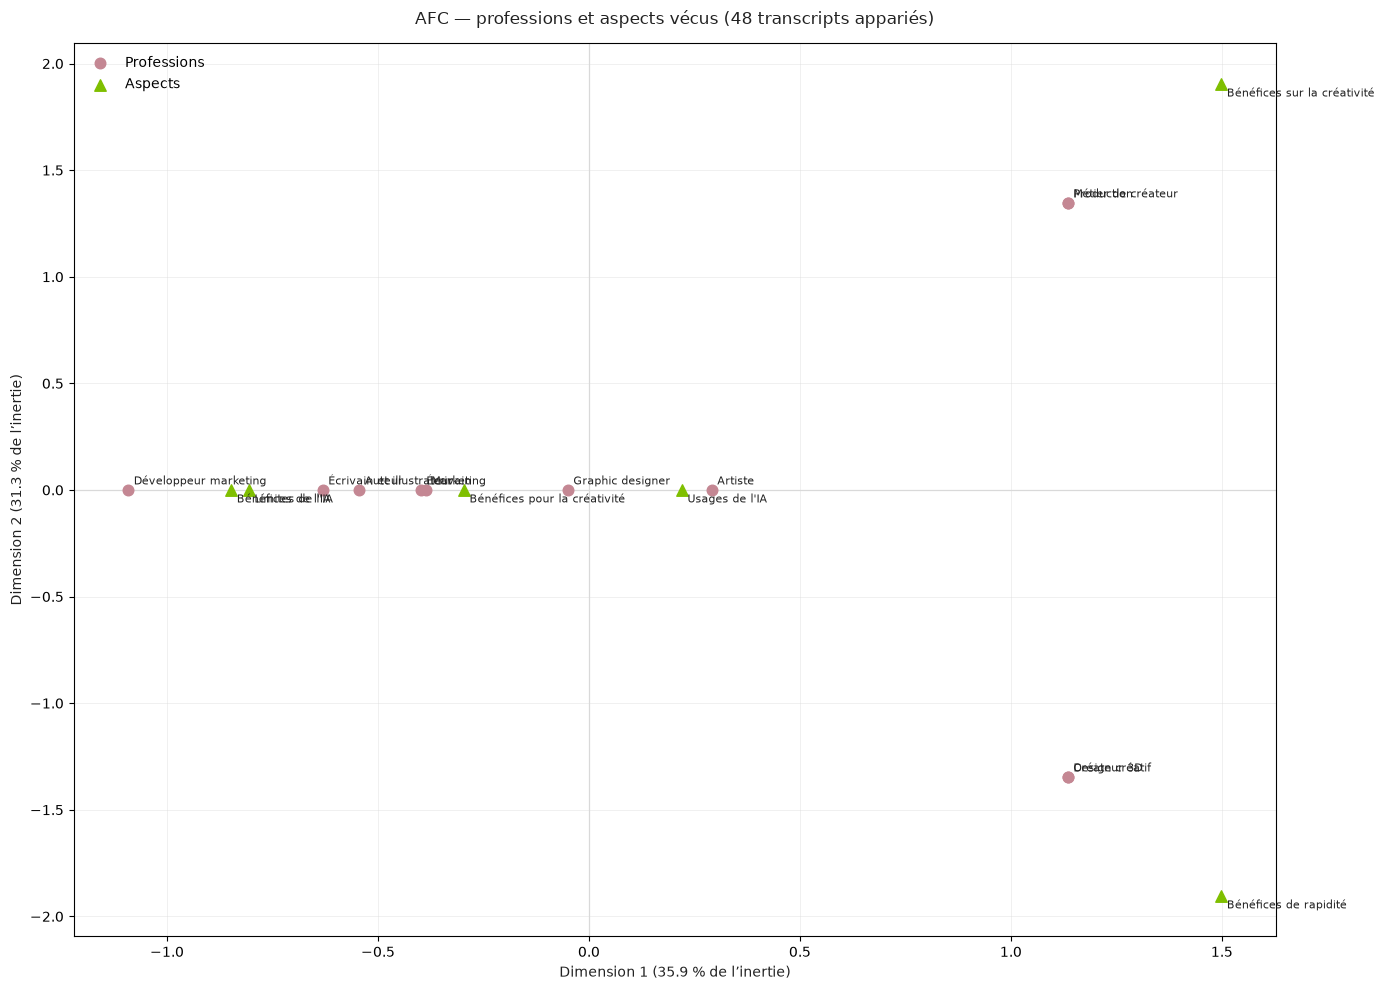

Transcripts appariés : 48 / 125
Transcripts sans profession ou aspect exploitable : 77
Modalités conservées pour l’AFC (seuil : 2) : 11 professions, 6 aspects
Paires écartées de la carte car rares : 115
Tableau croisé complet : /home/cbenavent/test/Mistral4/data/results/creatives_transcripts_profession_aspect_contingency_full.csv
Tableau utilisé pour l’AFC : /home/cbenavent/test/Mistral4/data/results/creatives_transcripts_profession_aspect_afc_modalities.csv
Coordonnées AFC : /home/cbenavent/test/Mistral4/data/results/creatives_transcripts_afc_coordinates_full.csv
Inertie : /home/cbenavent/test/Mistral4/data/results/creatives_transcripts_afc_inertia_full.csv
Carte factorielle : /home/cbenavent/test/Mistral4/images/creatives_transcripts_afc_professions_aspects_full.png
Inertie expliquée par les deux axes : 67.2 %


In [ ]:
import csv
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

profession_candidates = [
    Path("transcripts_job_types_full.csv"),
    Path("Mistral4/transcripts_job_types_full.csv"),
]
profession_path = next((path.resolve() for path in profession_candidates if path.is_file()), None)
if profession_path is None:
    raise FileNotFoundError(
        "transcripts_job_types_full.csv introuvable. "
        "Exécutez d'abord l'analyse complète des métiers sur transcripts_responses.csv."
    )

aspect_path = profession_path.with_name("transcripts_experience_aspects_top7_full.csv")
if not aspect_path.is_file():
    raise FileNotFoundError(
        f"{aspect_path.name} introuvable. Exécutez d'abord l'analyse complète des aspects (jusqu'à 7)."
    )

with profession_path.open("r", encoding="utf-8", newline="") as source_file:
    profession_reader = csv.DictReader(source_file)
    required_profession_columns = {"transcript_id", "job_type"}
    missing_profession_columns = required_profession_columns.difference(profession_reader.fieldnames or [])
    if missing_profession_columns:
        raise ValueError(f"Colonnes métier absentes : {sorted(missing_profession_columns)}")
    profession_rows = list(profession_reader)

ASPECT_COLUMNS = [f"aspect_{index}" for index in range(1, 8)]
with aspect_path.open("r", encoding="utf-8", newline="") as source_file:
    aspect_reader = csv.DictReader(source_file)
    required_aspect_columns = {"transcript_id", *ASPECT_COLUMNS}
    missing_aspect_columns = required_aspect_columns.difference(aspect_reader.fieldnames or [])
    if missing_aspect_columns:
        raise ValueError(f"Colonnes d'aspects absentes : {sorted(missing_aspect_columns)}")
    aspect_source_rows = list(aspect_reader)

profession_by_id = {}
for row in profession_rows:
    transcript_id = row["transcript_id"].strip()
    job_type = row["job_type"].strip()
    if transcript_id and job_type:
        if transcript_id in profession_by_id:
            raise ValueError(f"Profession répétée pour le transcript {transcript_id}.")
        profession_by_id[transcript_id] = job_type

joined_rows = []
unmatched_aspect_rows = 0
for row in aspect_source_rows:
    transcript_id = row["transcript_id"].strip()
    profession = profession_by_id.get(transcript_id)
    aspects = list(dict.fromkeys(
        row[column].strip()
        for column in ASPECT_COLUMNS
        if row[column].strip()
    ))
    if not profession or not aspects:
        unmatched_aspect_rows += 1
        continue
    joined_rows.append({"transcript_id": transcript_id, "profession": profession, "aspects": aspects})

if not joined_rows:
    raise ValueError("Aucune paire profession-aspect exploitable après l'appariement.")

MIN_MODALITY_COUNT = 2
profession_counts = Counter(row["profession"] for row in joined_rows)
aspect_counts = Counter(aspect for row in joined_rows for aspect in row["aspects"])
profession_labels = sorted(profession_counts, key=lambda label: (-profession_counts[label], label))
aspect_labels = sorted(aspect_counts, key=lambda label: (-aspect_counts[label], label))

full_contingency = np.zeros((len(profession_labels), len(aspect_labels)), dtype=float)
profession_index = {label: index for index, label in enumerate(profession_labels)}
aspect_index = {label: index for index, label in enumerate(aspect_labels)}
for row in joined_rows:
    for aspect in row["aspects"]:
        full_contingency[profession_index[row["profession"]], aspect_index[aspect]] += 1

# Iteratively remove rare modalities from the factor map, without merging labels.
active_rows = full_contingency.sum(axis=1) >= MIN_MODALITY_COUNT
active_columns = full_contingency.sum(axis=0) >= MIN_MODALITY_COUNT
while True:
    filtered = full_contingency[np.ix_(active_rows, active_columns)]
    retained_rows = filtered.sum(axis=1) >= MIN_MODALITY_COUNT
    retained_columns = filtered.sum(axis=0) >= MIN_MODALITY_COUNT
    row_indices = np.flatnonzero(active_rows)
    column_indices = np.flatnonzero(active_columns)
    next_rows = active_rows.copy()
    next_columns = active_columns.copy()
    next_rows[row_indices[~retained_rows]] = False
    next_columns[column_indices[~retained_columns]] = False
    if np.array_equal(next_rows, active_rows) and np.array_equal(next_columns, active_columns):
        break
    active_rows = next_rows
    active_columns = next_columns

profession_labels_afc = [label for label, keep in zip(profession_labels, active_rows) if keep]
aspect_labels_afc = [label for label, keep in zip(aspect_labels, active_columns) if keep]
contingency = full_contingency[np.ix_(active_rows, active_columns)]
if contingency.shape[0] < 2 or contingency.shape[1] < 2:
    raise ValueError("Trop peu de modalités fréquentes pour construire une AFC en deux dimensions.")

# Correspondence analysis: SVD of the standardized residual matrix.
grand_total = contingency.sum()
probabilities = contingency / grand_total
row_masses = probabilities.sum(axis=1)
column_masses = probabilities.sum(axis=0)
expected = np.outer(row_masses, column_masses)
standardized_residuals = (probabilities - expected) / np.sqrt(expected)
left_vectors, singular_values, right_vectors = np.linalg.svd(standardized_residuals, full_matrices=False)
eigenvalues = singular_values**2
total_inertia = eigenvalues.sum()
positive_dimensions = int(np.count_nonzero(eigenvalues > 1e-12))
if positive_dimensions < 2 or total_inertia <= 0:
    raise ValueError("Les données ne permettent pas de construire une carte AFC en deux dimensions.")

row_coordinates = (left_vectors[:, :2] / np.sqrt(row_masses[:, None])) * singular_values[:2]
column_coordinates = (right_vectors[:2, :].T / np.sqrt(column_masses[:, None])) * singular_values[:2]
explained_inertia = eigenvalues[:2] / total_inertia * 100

base_dir = profession_path.parent
results_dir = base_dir / "data" / "results"
images_dir = base_dir / "images"
results_dir.mkdir(parents=True, exist_ok=True)
images_dir.mkdir(parents=True, exist_ok=True)

contingency_path = results_dir / "transcripts_profession_aspect_contingency_top7_full.csv"
with contingency_path.open("w", encoding="utf-8", newline="") as output_file:
    writer = csv.writer(output_file)
    writer.writerow(["profession", *aspect_labels])
    for row_index, profession in enumerate(profession_labels):
        writer.writerow([profession, *full_contingency[row_index].astype(int).tolist()])

afc_table_path = results_dir / "transcripts_profession_aspect_afc_modalities_top7.csv"
with afc_table_path.open("w", encoding="utf-8", newline="") as output_file:
    writer = csv.writer(output_file)
    writer.writerow(["profession", *aspect_labels_afc])
    for row_index, profession in enumerate(profession_labels_afc):
        writer.writerow([profession, *contingency[row_index].astype(int).tolist()])

coordinates_path = results_dir / "transcripts_afc_coordinates_top7_full.csv"
with coordinates_path.open("w", encoding="utf-8", newline="") as output_file:
    writer = csv.DictWriter(
        output_file,
        fieldnames=["categorie", "libelle", "dimension_1", "dimension_2", "masse"],
    )
    writer.writeheader()
    for index, label in enumerate(profession_labels_afc):
        writer.writerow({
            "categorie": "Profession",
            "libelle": label,
            "dimension_1": row_coordinates[index, 0],
            "dimension_2": row_coordinates[index, 1],
            "masse": row_masses[index],
        })
    for index, label in enumerate(aspect_labels_afc):
        writer.writerow({
            "categorie": "Aspect",
            "libelle": label,
            "dimension_1": column_coordinates[index, 0],
            "dimension_2": column_coordinates[index, 1],
            "masse": column_masses[index],
        })

inertia_path = results_dir / "transcripts_afc_inertia_top7_full.csv"
with inertia_path.open("w", encoding="utf-8", newline="") as output_file:
    writer = csv.DictWriter(output_file, fieldnames=["dimension", "inertie", "pourcentage_inertie"])
    writer.writeheader()
    for index, value in enumerate(eigenvalues, start=1):
        writer.writerow({
            "dimension": index,
            "inertie": value,
            "pourcentage_inertie": value / total_inertia * 100,
        })

fig, ax = plt.subplots(figsize=(14, 10), facecolor="#FFFFFF")
ax.set_facecolor("#FFFFFF")
ax.axhline(0, color="#D9D9D9", linewidth=0.9, zorder=0)
ax.axvline(0, color="#D9D9D9", linewidth=0.9, zorder=0)
ax.grid(color="#D9D9D9", linewidth=0.5, alpha=0.55)

profession_color = "#C48793"
aspect_color = "#7FBF00"
ax.scatter(row_coordinates[:, 0], row_coordinates[:, 1], color=profession_color, marker="o", s=58, label="Professions", zorder=3)
ax.scatter(column_coordinates[:, 0], column_coordinates[:, 1], color=aspect_color, marker="^", s=68, label="Aspects", zorder=3)
for index, label in enumerate(profession_labels_afc):
    ax.annotate(label, row_coordinates[index], xytext=(4, 4), textcoords="offset points", fontsize=8, color="#222222")
for index, label in enumerate(aspect_labels_afc):
    ax.annotate(label, column_coordinates[index], xytext=(4, -9), textcoords="offset points", fontsize=8, color="#222222")

ax.set_title(
    f"AFC — professions et aspects vécus ({len(joined_rows)} transcripts appariés)",
    color="#222222",
    pad=14,
)
ax.set_xlabel(f"Dimension 1 ({explained_inertia[0]:.1f} % de l’inertie)", color="#222222")
ax.set_ylabel(f"Dimension 2 ({explained_inertia[1]:.1f} % de l’inertie)", color="#222222")
ax.legend(frameon=False)
fig.tight_layout()
figure_path = images_dir / "transcripts_afc_professions_aspects_top7_full.png"
fig.savefig(figure_path, dpi=180, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

print(f"Transcripts appariés : {len(joined_rows)} / {len(aspect_source_rows)}")
print(f"Transcripts sans profession ou aspect exploitable : {unmatched_aspect_rows}")
print(f"Modalités conservées pour l’AFC (seuil : {MIN_MODALITY_COUNT}) : {len(profession_labels_afc)} professions, {len(aspect_labels_afc)} aspects")
print(f"Paires écartées de la carte car rares : {int(full_contingency.sum() - contingency.sum())}")
print(f"Tableau croisé complet : {contingency_path}")
print(f"Tableau utilisé pour l’AFC : {afc_table_path}")
print(f"Coordonnées AFC : {coordinates_path}")
print(f"Inertie : {inertia_path}")
print(f"Carte factorielle : {figure_path}")
print(f"Inertie expliquée par les deux axes : {explained_inertia.sum():.1f} %")

### Étiquettes repel

Ajuster automatiquement les étiquettes pour limiter les chevauchements, avec un trait de rappel vers chaque modalité.

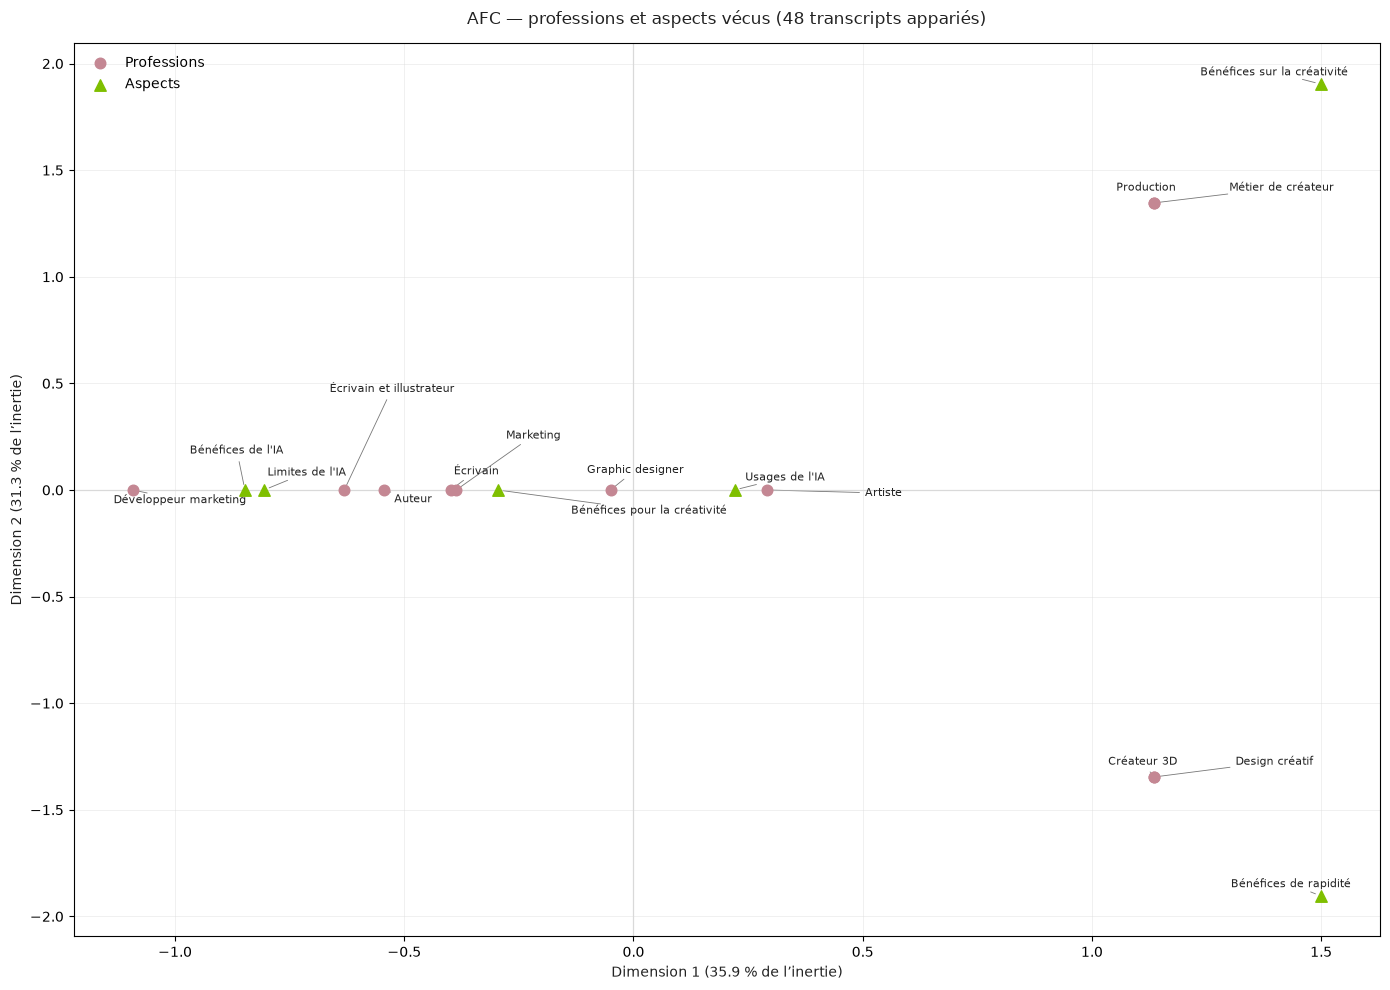

Carte AFC avec étiquettes repel : /home/cbenavent/test/Mistral4/images/creatives_transcripts_afc_professions_aspects_full.png


In [ ]:
from adjustText import adjust_text

plt.close(fig)
fig, ax = plt.subplots(figsize=(14, 10), facecolor="#FFFFFF")
ax.set_facecolor("#FFFFFF")
ax.axhline(0, color="#D9D9D9", linewidth=0.9, zorder=0)
ax.axvline(0, color="#D9D9D9", linewidth=0.9, zorder=0)
ax.grid(color="#D9D9D9", linewidth=0.5, alpha=0.55)

ax.scatter(row_coordinates[:, 0], row_coordinates[:, 1], color=profession_color, marker="o", s=58, label="Professions", zorder=3)
ax.scatter(column_coordinates[:, 0], column_coordinates[:, 1], color=aspect_color, marker="^", s=68, label="Aspects", zorder=3)

label_texts = []
target_x = []
target_y = []
for index, label in enumerate(profession_labels_afc):
    x_coord, y_coord = row_coordinates[index]
    label_texts.append(ax.text(x_coord, y_coord, label, fontsize=8, color="#222222"))
    target_x.append(x_coord)
    target_y.append(y_coord)
for index, label in enumerate(aspect_labels_afc):
    x_coord, y_coord = column_coordinates[index]
    label_texts.append(ax.text(x_coord, y_coord, label, fontsize=8, color="#222222"))
    target_x.append(x_coord)
    target_y.append(y_coord)

adjust_text(
    label_texts,
    x=target_x,
    y=target_y,
    target_x=target_x,
    target_y=target_y,
    ax=ax,
    expand=(1.35, 1.6),
    force_text=(0.8, 0.9),
    force_static=(0.2, 0.35),
    force_pull=(0.005, 0.01),
    force_explode=(0.35, 0.8),
    max_move=25,
    iter_lim=1500,
    arrowprops={"arrowstyle": "-", "color": "#777777", "linewidth": 0.6, "shrinkA": 4, "shrinkB": 4},
)

ax.set_title(
    f"AFC — professions et aspects vécus ({len(joined_rows)} transcripts appariés)",
    color="#222222",
    pad=14,
)
ax.set_xlabel(f"Dimension 1 ({explained_inertia[0]:.1f} % de l’inertie)", color="#222222")
ax.set_ylabel(f"Dimension 2 ({explained_inertia[1]:.1f} % de l’inertie)", color="#222222")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(figure_path, dpi=180, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"Carte AFC avec étiquettes repel : {figure_path}")